# Ajustement de cercles et d'Ellipses

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.optimize import least_squares

### Méthode 2 — Ajustement non linéaire par moindres carrés géométriques

On note
$
\theta=(x_c,y_c,r)\in\mathbb{R}^2\times\mathbb{R}_+.
$

La fonction à minimiser est :
$
F(\theta) =\sum_{i=1}^n\left(\sqrt{(x_i-x_c)^2+(y_i-y_c)^2}-r\right)^2
=\sum_{i=1}^n \rho_i(\theta)^2
$

en notant
$
\rho_i(\theta)=\sqrt{(x_i-x_c)^2+(y_i-y_c)^2}-r
$ , le résidu géométrique

---
### Existence d’un minimiseur

La fonction $F$ est continue sur $\mathbb{R}^2\times\mathbb{R}_+$.

- A $(x_c,y_c)$ fixé, la fonction $r\mapsto F(x_c,y_c,r)$ est convexe et son gradient s'annule, elle admet donc un minimum.
- A $r$ fixé, $(x_c,y_c)\mapsto F(x_c,y_c,r)$ est infini à l'infini, donc elle admet au moins un minimimum.

F admet donc au moins un minimiseur $\theta^*$

---

### Formulation vectorielle

On introduit le vecteur des résidus

$
\rho(\theta)=
\begin{pmatrix}
\rho_1(\theta)\\
\vdots\\
\rho_n(\theta)
\end{pmatrix}
\in\mathbb{R}^n
$

On a alors $F(\theta)=\|\rho(\theta)\|_2^2$

---

### Aproximation du minimiseur par la methode de Gausse-Newton

On construit une suite $(\theta_n)_{n\ge0}$ convergent vert $\theta^*$.


Soit $n \in \mathbb{N}$ et $\theta_n > 0$ la fonction $\rho$ étant $\mathcal C^1$, pour tout $h$ on a:

$$\rho(\theta_n+h)=\rho(\theta_n)+J(\theta_n)h+o(\|h\|)$$

où $J(\theta_n)\in\mathbb{R}^{n\times3}$ est la jacobienne de $\rho$ en $\theta_n$.

Ainsi $$F(\theta_n+h)=\approx\|\rho(\theta_n)+J(\theta_n)h\|^2$$

D'après la formule de l'estimateur des moindres carrées obtenu par annulation du gradient, Si $J(\theta_n)^T J(\theta_n)$ est inversible, cette quantité est minimisée par :

$$h^*= -(J(\theta_n)^T J(\theta_n))^{-1}J(\theta_n)^T\rho(\theta_n)$$

on note alors $h^*:=h_n$ et $\theta_{n+1}=\theta_n+h_n$

et par definition d'un minimiseur, 

$$F(\theta_{n+1})=F(\theta_n+h_n)<F(\theta_n + 0)$$

Donc la suite ainsi défini converge bien vers le minimiseur.


---

### Méthode de Levenberg–Marquardt

Afin d’améliorer la stabilité numérique, on considère la minimisation régularisée

$\min_h\|\rho(\theta_n)+J(\theta_n)h\|^2+\lambda_n\|h\|^2,\qquad \lambda_n>0$

En calculant le zéro du gradient on trouve que le minimiseur $h^*$ vérifie cette fois:

$$h^*=-(J(\theta_n)^T J(\theta_n)+\lambda_n I)^{-1}J(\theta_n)^T\rho(\theta_n)$$

Ou $J(\theta_n)^T J(\theta_n)+\lambda_n I$ est définie positive pour $\lambda_n>0$, ce qui garantit l’inversibilité du système.

Et on définit de la même façon $\theta_{n+1}=\theta_n+h_n$

La méthode de Levenberg–Marquardt concilie deux methodes :

- La descente de gradient pour $\lambda_n$ grand
- la méthode de Gauss–Newton pour $\lambda_n$ petit

Elle offre ainsi une meilleure robustesse loin du minimum tout en conservant une convergence rapide au voisinage de la solution.

---
### implémentation

Le code ci-dessous implémente la méthode 2 pour calculer $\theta^*$ à partir d'un jeu de donnée. 

In [ ]:
#minimisation sans contrainte
def methode2(x, y, method='lm',max_nfev=1000):
    '''
    minimisation sans contraintes
    Datas (x,y)
    par défaut methode Levenberg-Marquardt avec régularisation
    précision?
    '''
    #definition de la fonction des residus
    def residus(theta):
        xc, yc, r = theta
        return np.sqrt((x-xc)**2 + (y-yc)**2) - r
    
    # initialisation
    xc0 = np.mean(x)
    yc0 = np.mean(y)
    r0  = np.mean(np.sqrt((x-xc0)**2 + (y-yc0)**2))

    result = least_squares(residus, x0=(xc0, yc0, r0), method=method, max_nfev=max_nfev)  #max nombre d'itération1000
    #voir vitesse de convergence et critère d'arret
    
    return result.x
#LM est une version améliorée de la methode de Gausse-Newton, étudier la convergence de la suite des paramêtres

---

### Méthode 3 — Ajustement non linéaire par moindres carrés géométriques avec contrainte

On ajoute à la methode 2 la contrainte suivante: le point $(x_n,y_n)$ appartient au cercle. Le rayon est alors entièrement déterminé par ce point et les paramêtres $(x_c,y_c)$.
$$r=\sqrt{(x_n-x_c)^2 + (y_n -y_c)^2}$$

In [5]:
def methode3(x,y, method='lm',max_nfev=1000):
    '''
    minimisation avec contrainte
    Datas (x,y)
    par défaut methode Levenberg-Marquardt avec régularisation
    '''

    #definition avec contrainte
    def residus(theta):
        xc, yc = theta #2 paramêtres car r dépend de xc et yc
        r = np.mean(np.sqrt((x[-1]-xc)**2 + (y[-1]-yc)**2))
        return np.sqrt((x-xc)**2 + (y-yc)**2) - r
    
    # initialisation
    xc0 = np.mean(x)
    yc0 = np.mean(y)

    result = least_squares(residus, x0=(xc0, yc0), method=method, max_nfev=max_nfev)  #max nombre d'itération1000
    
    xc,yc = result.x
    r=np.sqrt((x[-1]-xc)**2 + (y[-1]-yc)**2)

    return xc,yc,r

---

### Test sur un jeu de données créé

In [6]:
random.seed()

#création d'un jeu de données de test

n=100 #nombre de points

# selection de points issus du vrai cercle
r=3 #rayon du vrai cercle
theta = np.random.uniform(0, 2*np.pi, 100) 
x = r * np.cos(theta) 
y = r * np.sin(theta)

#bruitage des points
sigma=0.5
bruit = np.random.normal(loc=0, scale=np.sqrt(sigma), size=(n, 2))
x_bruite = x + bruit[:,0]
y_bruite = y + bruit[:,1]

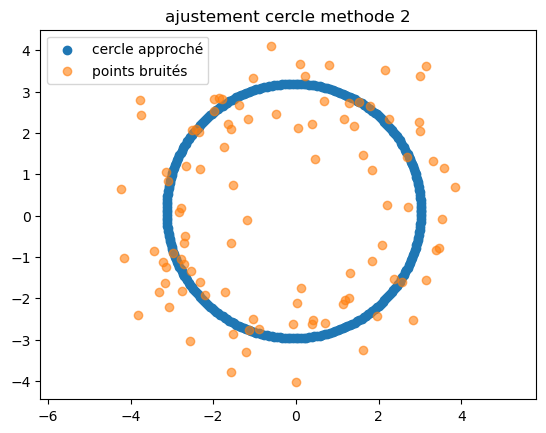

In [10]:
#visualisation methode 2

xc, yc, r =methode2(x_bruite,y_bruite)
theta = np.linspace(0, 2*np.pi, 300)
x_cercle = xc + r*np.cos(theta)
y_cercle = yc + r*np.sin(theta)
plt.scatter(x_cercle, y_cercle, label="cercle approché")
plt.scatter(x_bruite, y_bruite, alpha=0.6, label="points bruités")

plt.axis("equal")
plt.title("ajustement cercle methode 2")
plt.legend()
plt.show()


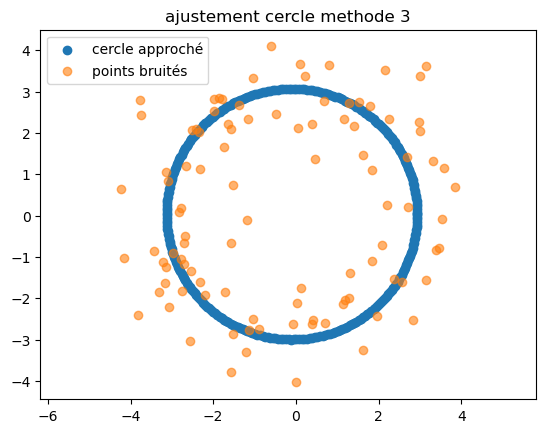

In [11]:
#visulaisation methode 3

xc, yc, r =methode3(x_bruite,y_bruite)
theta = np.linspace(0, 2*np.pi, 300)
x_cercle = xc + r*np.cos(theta)
y_cercle = yc + r*np.sin(theta)
plt.scatter(x_cercle, y_cercle, label="cercle approché")
plt.scatter(x_bruite, y_bruite, alpha=0.6, label="points bruités")

plt.axis("equal")
plt.title("ajustement cercle methode 3")
plt.legend()
plt.show()